# Binary classification models

In [ ]:
%%capture
!cmd /c dependencies.bat

## Dependencies

In [1]:
import tensorflow as tf
print("Dispositivos GPU:", tf.config.list_physical_devices('GPU'))

Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 17015595668064126410
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3760193536
locality {
  bus_id: 1
  links {
  }
}
incarnation: 9282247099853416215
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from collections import defaultdict
import torch
import time
import os

In [4]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [6]:
random.seed(42)
tf.random.set_seed(42)

In [7]:
from functions.functions import * 

## Data 12000 images

In [8]:
path_renders = "..\\capturas\\capturas_256x256\\ClassBin"

In [9]:
database = os.listdir(path_renders)
data_img_labels = database[0]
imgs = database[1:]
print(database[:10])
print(imgs[-1])

['dataBin.csv', 'render_0000.png', 'render_0001.png', 'render_0002.png', 'render_0003.png', 'render_0004.png', 'render_0005.png', 'render_0006.png', 'render_0007.png', 'render_0008.png']
render_9999.png


In [10]:
csv_path = os.path.join(path_renders, data_img_labels)

df = pd.read_csv(csv_path, header =0, names=["filename", "correcto"])

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_renders, x))


print(df[["filename", "correcto"]].tail())

               filename  correcto
11994  render_11994.png     False
11995  render_11995.png     False
11996  render_11996.png      True
11997  render_11997.png      True
11998  render_11998.png      True


In [11]:
for p in imgs[:10]:    
    img_path = os.path.join(path_renders, p)
    print(img_path)

..\capturas\capturas_256x256\ClassBin\render_0000.png
..\capturas\capturas_256x256\ClassBin\render_0001.png
..\capturas\capturas_256x256\ClassBin\render_0002.png
..\capturas\capturas_256x256\ClassBin\render_0003.png
..\capturas\capturas_256x256\ClassBin\render_0004.png
..\capturas\capturas_256x256\ClassBin\render_0005.png
..\capturas\capturas_256x256\ClassBin\render_0006.png
..\capturas\capturas_256x256\ClassBin\render_0007.png
..\capturas\capturas_256x256\ClassBin\render_0008.png
..\capturas\capturas_256x256\ClassBin\render_0009.png


## Auxiliary functions

In [12]:
def get_paths_and_labels(df, test_size=0.2):
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()
    
    encoder = LabelEncoder()
    df_valid['label_encoded'] = encoder.fit_transform(df_valid['correcto'])
    
    paths = df_valid['full_path'].values
    labels = df_valid['label_encoded'].values
    
    # train test (80/20)
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        paths, labels, test_size=test_size, random_state=42, stratify=labels
    )

    # train val (80/20)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.2, random_state=42, stratify=train_val_labels
    )

    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder


def load_image_tf(path, label, method):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    
    if method == "resnet":
        img = tf.cast(img, tf.float32) / 255.0
    elif method == "efficientnet":
        img = tf.cast(img, tf.float32) 
    elif method == "mobilenet":
        img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    return img, label

In [13]:
def training_pipeline_db(model, train_ds, val_ds, test_ds, patience=3, epochs=10, lr=0.005):

    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, decay=1e-4) # original value = 1e-5
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = (patience * 2),  # esperamos patience*2 para ver si reducir lr mejora
        verbose = 1,
        restore_best_weights = True # devolver mejores pesos guardados
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]    )


    history = model.fit(
        train_ds, 
        epochs=epochs, 
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

    print("\nEvaluando en Entrenamiento...")
    results_train = model.evaluate(train_ds, verbose=0)
    train_loss = results_train[0]
    train_acc = results_train[1]

    print("Evaluando en Test...")
    results_test = model.evaluate(test_ds, verbose=0)
    test_loss = results_test[0]
    test_acc = results_test[1]

    final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
    
    return test_acc, train_acc, train_loss, test_loss, history, final_lr

## Get Dataset

In [14]:
(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder = get_paths_and_labels(df, test_size=0.2)

print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(train_paths) + len(val_paths) + len(test_paths)}")
print(f"Entrenamiento: {len(train_paths)}")
print(f"Validación:    {len(val_paths)}")
print(f"Test:          {len(test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(df['correcto'].value_counts())
print(df['correcto'].value_counts(normalize=True) * 100)

[False  True]
ID 0 -> Clase: False
ID 1 -> Clase: True
Total: 11999
Entrenamiento: 7679
Validación:    1920
Test:          2400

Distribución de clases en el dataset completo:
correcto
False    6032
True     5967
Name: count, dtype: int64
correcto
False    50.270856
True     49.729144
Name: proportion, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_30988\2423435773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='correcto', data=df, palette='viridis')


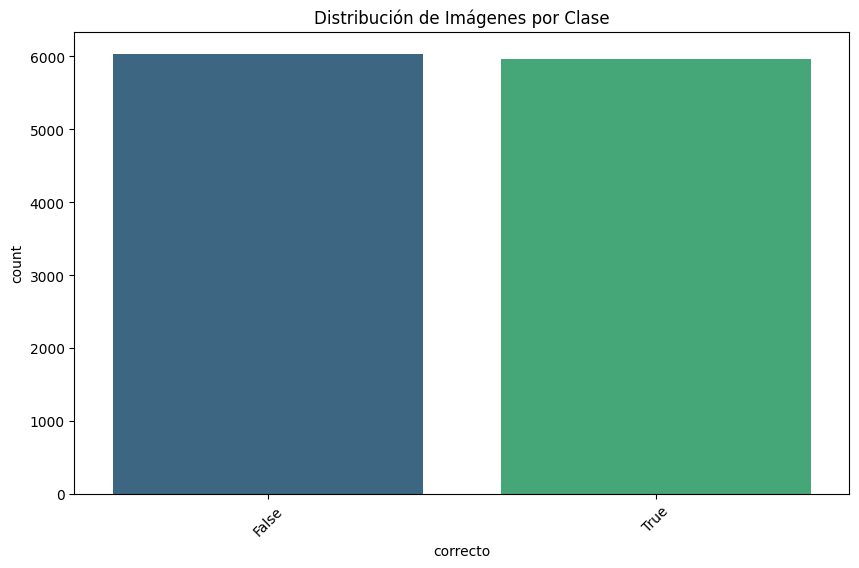

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='correcto', data=df, palette='viridis')
plt.title('Distribución de Imágenes por Clase')
plt.xticks(rotation=45)
plt.show()

In [15]:
batch_size = 32
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

## Models

### Load models


In [16]:
model_bin_mobilenet = load_model("binModels\model_bin_mobilenet.h5")
history_bin_mobilenet = load_history("binHistories\history_bin_mobilenet.pkl")

Historial cargado desde binHistories\history_bin_mobilenet.pkl.


In [ ]:
model_bin_mobilenetV2 = load_model("binModels\model_bin_mobilenetV2.h5")
history_bin_mobilenetV2 = load_history("binHistories\history_bin_mobilenetV2.pkl")

Historial cargado desde histories\history_bin_mobilenetV2.pkl.


### MobileNet

In [16]:
from tensorflow.keras.applications import MobileNet

#### 15 epochs

In [17]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_bin_mobilenet = Sequential([
    base_mobilenet,
    layers.Dropout(0.5),   # evita overfitting
    layers.Dense(1, activation='sigmoid')   # 2 clases
])

# hay más datos, añadimos más epochs
epochs = 15

test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_bin_mobilenet, final_lr = training_pipeline_db(model_bin_mobilenet, train_ds, val_ds, test_ds, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/15
240/240 [==============================] - 48s 187ms/step - loss: 0.2349 - accuracy: 0.9043 - precision: 0.8798 - recall: 0.9353 - val_loss: 0.4470 - val_accuracy: 0.8745 - val_precision: 0.7985 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 2/15
240/240 [==============================] - 47s 195ms/step - loss: 0.0705 - accuracy: 0.9767 - precision: 0.9664 - recall: 0.9874 - val_loss: 0.0674 - val_accuracy: 0.9786 - val_precision: 0.9588 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 3/15
240/240 [==============================] - 45s 187ms/step - loss: 0.0220 - accuracy: 0.9934 - precision: 0.9888 - recall: 0.9979 - val_loss: 0.0497 - val_accuracy: 0.9849 - val_precision: 0.9705 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 4/15
240/240 [==============================] - 60s 251ms/step - loss: 0.0088 - accuracy: 0.9971 - precision: 0.9956 - recall: 0.9987 - val_loss: 0.0335 - val_accuracy: 0.9885 - val_precision: 0.9775 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 5/15
240/240 [====

In [18]:
model_bin_mobilenet.save("binModels\model_bin_mobilenet.h5")
save_history(history_bin_mobilenet, "binHistories\history_bin_mobilenet.pkl")

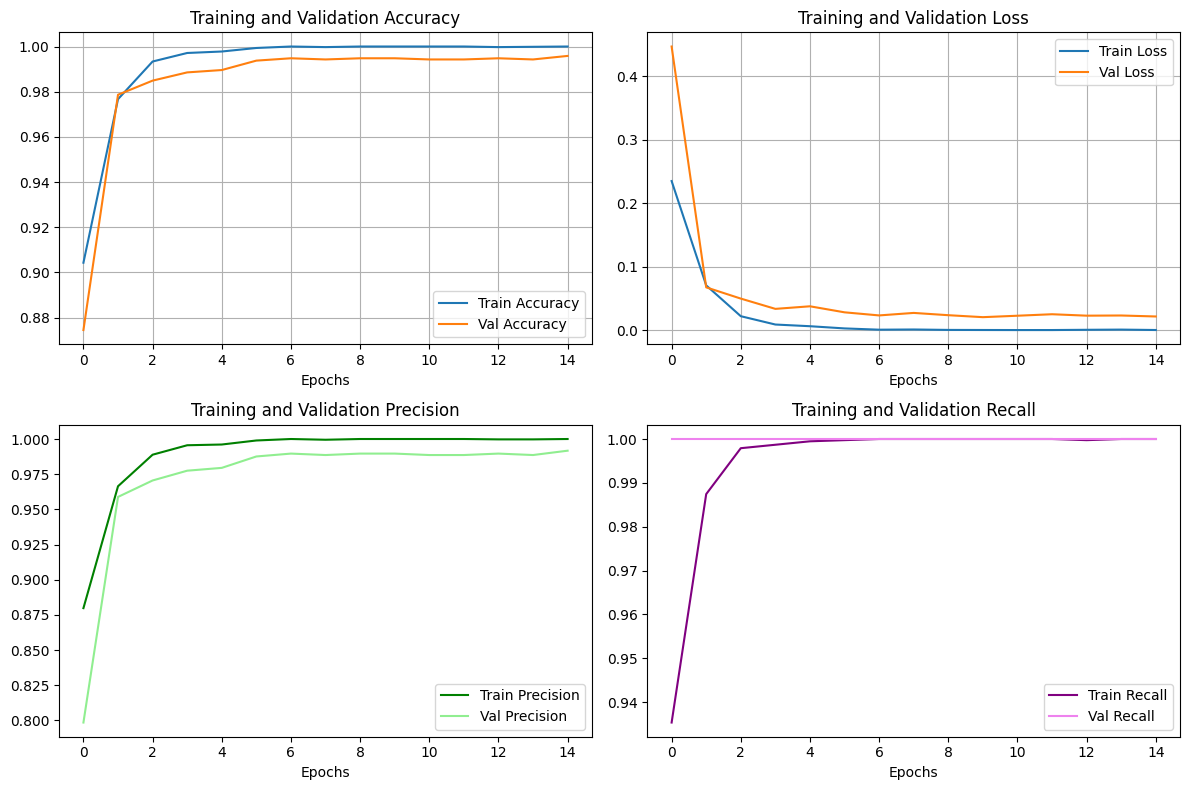

In [19]:
plot_from_history(history_bin_mobilenet, epochs = epochs)

In [17]:
y_pred_mobilenet = model_bin_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = (y_pred_mobilenet > 0.5).astype(int).flatten()
class_names = encoder.classes_ 
class_names = [str(name) for name in class_names]

acc_mobilenet = accuracy_score(test_labels, y_pred_classes_mobilenet)
print(f"Accuracy MobileNet: {acc_mobilenet}")
print("-------------------------------------")

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

75/75 [==============================] - 4s 40ms/step
Accuracy MobileNet: 0.9966666666666667
-------------------------------------
F1 Score MobileNet: 0.9966666944446181
-------------------------------------
Classification Report MobileNet:
              precision    recall  f1-score   support

       False       1.00      0.99      1.00      1207
        True       0.99      1.00      1.00      1193

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [18]:
tn, fp, fn, tp =show_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

=== MATRIZ DE CONFUSIÓN BINARIA ===
Metrica              | Valor      | Interpretación
------------------------------------------------------------
Verdaderos Neg. (TN) | 1199       | Correctos: False
Falsos Pos. (FP)     | 8          | Error: Era False pero predijo True
Falsos Neg. (FN)     | 0          | Error: Era True pero predijo False
Verdaderos Pos. (TP) | 1193       | Correctos: True
------------------------------------------------------------
Estado de la clase True: OK


In [19]:
index_fn = np.where((test_labels == 1) & (y_pred_classes_mobilenet == 0))[0]
index_fp = np.where((test_labels == 0) & (y_pred_classes_mobilenet == 1))[0] 

FALSOS POSITIVOS: 8
=========== FALSOS POSITIVOS ===========


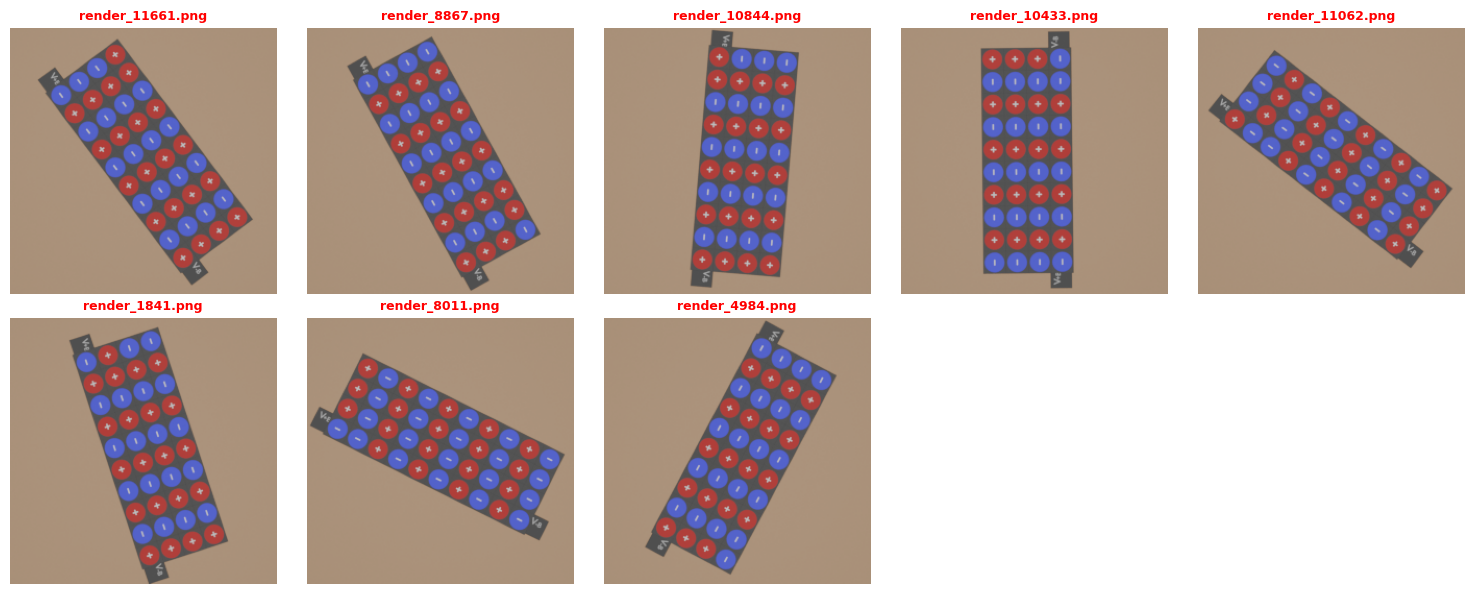

In [20]:
show_false_labeling(index_fp, "FALSOS POSITIVOS", test_paths)

Muchos de los FP tienen pocas pilas mal $\rightarrow$ crear más imágenes que tengan de 1 a 5 pilas mal colocadas

### Comparación



##### Entrenamiento de 10 epochs seguidas 12000 imágenes

Train, test y val con datos capturados desde Blender

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1030 | Correctos: False                            |
| Falsos Pos. (FP)       |   177 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |   104 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1089 | Correctos: True                             |
   
val_loss de 0.4 -> añadimos más epochs

##### Entrenamiento con 15 epochs seguidas 12000 imágenes
lr=0.0001 + dropout 0.5 + Adam

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1112 | Correctos: False                            |
| Falsos Pos. (FP)       |    95 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |   136 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1057 | Correctos: True                             |

val_loss sigue siendo alto pero:  

- Accuracy MobileNet: 0.90375
- F1 Score MobileNet: 0.9037122989938291

| Clase   | Precision | Recall | F1-score | Support |
|---------|----------:|-------:|---------:|--------:|
| False   |      0.89 |   0.92 |     0.91 |    1207 |
| True    |      0.92 |   0.89 |     0.90 |    1193 |
| Accuracy|           |        |     0.90 |    2400 |
| Macro avg |     0.90 |   0.90 |     0.90 |    2400 |
| Weighted avg |  0.90 |   0.90 |     0.90 |    2400 |

##### Entrenamiento con 15 epochs seguidas 12000 imágenes + pesos imagenet
lr=0.0001 + dropout 0.5 + Adam 

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1200 | Correctos: False                            |
| Falsos Pos. (FP)       |     7 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |     0 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1193 | Correctos: True                             |


##### 15 epochs + lr=0.0001 + dropout 0.5 + AdamW

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1139 | Correctos: False                            |
| Falsos Pos. (FP)       |    68 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |    13 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1180 | Correctos: True                             |

#### MobileNetV2

##### 15 epochs + lr=0.0001 + dropout 0.5 + AdamW + patience = 5 + imagenet weights
sin los pesos de imagenet el acc es de ~0.54

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1206 | Correctos: False                            |
| Falsos Pos. (FP)       |     1 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |     0 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1193 | Correctos: True                             |

### MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
start_time = time.time()

base_mobilenetV2 = MobileNetV2(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_bin_mobilenetV2 = Sequential([
    base_mobilenetV2,
    layers.Dropout(0.5),  
    layers.Dense(1, activation='sigmoid')   # 2 clases
])

epochs = 15 # cambiar patience

test_acc_mobilenetV2, train_acc_mobilenetV2, train_loss_mobilenetV2, test_loss_mobilenetV2, history_bin_mobilenetV2, final_lr = training_pipeline_db(model_bin_mobilenetV2, train_ds, val_ds, test_ds, patience = 5, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_mobilenetV2}\nTrain accuracy: {train_acc_mobilenetV2}")
print(f"Test loss: {test_loss_mobilenetV2}\nTrain loss: {train_loss_mobilenetV2}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/15
480/480 [==============================] - 109s 217ms/step - loss: 0.1896 - accuracy: 0.9224 - precision_2: 0.9048 - recall_2: 0.9432 - val_loss: 0.4634 - val_accuracy: 0.8000 - val_precision_2: 0.7132 - val_recall_2: 1.0000 - lr: 1.0000e-04
Epoch 2/15
480/480 [==============================] - 108s 225ms/step - loss: 0.0206 - accuracy: 0.9947 - precision_2: 0.9909 - recall_2: 0.9984 - val_loss: 0.0776 - val_accuracy: 0.9724 - val_precision_2: 0.9474 - val_recall_2: 1.0000 - lr: 1.0000e-04
Epoch 3/15
480/480 [==============================] - 111s 232ms/step - loss: 0.0113 - accuracy: 0.9973 - precision_2: 0.9966 - recall_2: 0.9979 - val_loss: 0.0033 - val_accuracy: 0.9990 - val_precision_2: 0.9979 - val_recall_2: 1.0000 - lr: 1.0000e-04
Epoch 4/15
480/480 [==============================] - 114s 238ms/step - loss: 0.0082 - accuracy: 0.9978 - precision_2: 0.9971 - recall_2: 0.9984 - val_loss: 0.0083 - val_accuracy: 0.9984 - val_precision_2: 0.9969 - val_recall_2: 1.0000 - lr:

In [ ]:
model_bin_mobilenetV2.save("binModels\model_bin_mobilenetV2.h5")
save_history(history_bin_mobilenetV2, "binHistories\history_bin_mobilenetV2.pkl")

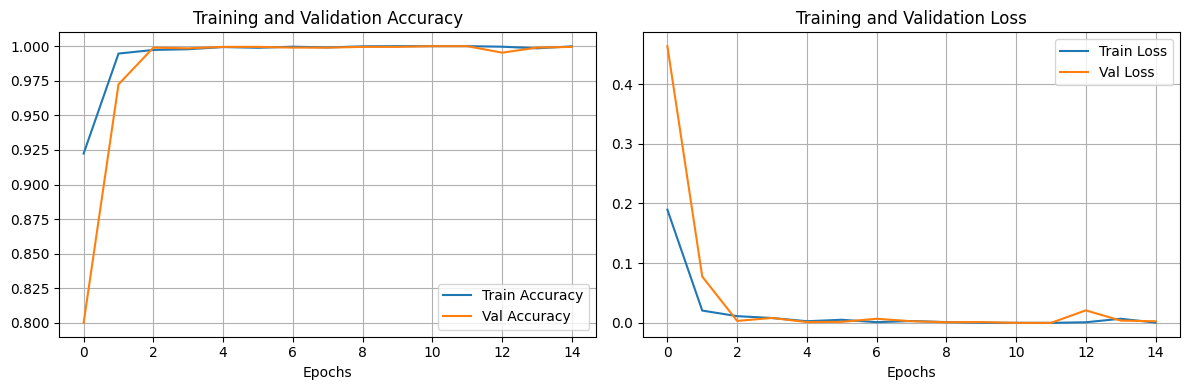

In [ ]:
plot_from_history(history_bin_mobilenetV2, epochs = epochs)

In [ ]:
y_pred_mobilenetV2 = model_bin_mobilenetV2.predict(test_ds)
y_pred_classes_mobilenetV2 = (y_pred_mobilenetV2 > 0.5).astype(int).flatten()
class_names = encoder.classes_ 
class_names = [str(name) for name in class_names]

acc_mobilenetV2 = accuracy_score(test_labels, y_pred_classes_mobilenetV2)
print(f"Accuracy MobileNetV2: {acc_mobilenetV2}")
print("-------------------------------------")

f1_mobilenetV2 = f1_score(test_labels, y_pred_classes_mobilenetV2, average="weighted")
print(f"F1 Score MobileNetV2: {f1_mobilenetV2}")
print("-------------------------------------")

print("Classification Report MobileNetV2:")
print(classification_report(test_labels, y_pred_classes_mobilenetV2, target_names=class_names))

75/75 [==============================] - 61s 800ms/step
Accuracy MobileNetV2: 0.9995833333333334
-------------------------------------
F1 Score MobileNetV2: 0.9995833322482216
-------------------------------------
Classification Report MobileNetV2:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1207
        True       1.00      1.00      1.00      1193

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [ ]:
tn, fp, fn, tp =show_confusion_matrix(test_labels, y_pred_classes_mobilenetV2, class_names)

=== MATRIZ DE CONFUSIÓN BINARIA ===
Metrica              | Valor      | Interpretación
------------------------------------------------------------
Verdaderos Neg. (TN) | 1207       | Correctos: False
Falsos Pos. (FP)     | 0          | Error: Era False pero predijo True
Falsos Neg. (FN)     | 1          | Error: Era True pero predijo False
Verdaderos Pos. (TP) | 1192       | Correctos: True
------------------------------------------------------------
Estado de la clase True: OK


In [ ]:
index_fn = np.where((test_labels == 1) & (y_pred_classes_mobilenetV2 == 0))[0]
index_fp = np.where((test_labels == 0) & (y_pred_classes_mobilenetV2 == 1))[0] 

FALSOS NEGATIVOS: 1
=========== FALSOS NEGATIVOS ===========


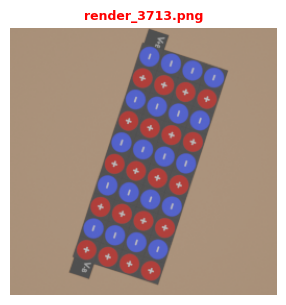

In [ ]:
show_false_labeling(index_fn, "FALSOS NEGATIVOS", test_paths)

# ---------------------------

In [ ]:
def get_real_test_dataset():
    path =  "../capturas/capturas_256x256/capturasVR"
    database = os.listdir(path)
    data_img_labels = database[0]

    csv_path = os.path.join(path, data_img_labels)

    df = pd.read_csv(csv_path, header =0, names=["filename", "label"])

    df["full_path"] = df["filename"].apply(lambda x: os.path.join(path, x))
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()
    
    encoder = LabelEncoder()
    df_valid['label_encoded'] = encoder.fit_transform(df_valid['label'])
    
    df_class_2 = df_valid[df_valid['label_encoded'] == 2].copy()
    df_class_2['label_binary'] = True   
    
    paths = df_class_2['full_path'].values
    labels = df_class_2['label_binary'].values

    return tf.data.Dataset.from_tensor_slices((paths, labels))

In [ ]:
real_test_ds = get_real_test_dataset()
real_test_ds = (real_test_ds
           .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

y_true_list = []
for images, labels in real_test_ds:
    y_true_list.append(labels.numpy())

y_true_real = np.concatenate(y_true_list, axis=0)

y_pred_real = model_bin_mobilenet.predict(real_test_ds)
y_pred_classes_real= (y_pred_real > 0.5).astype(int).flatten()

class_names_real = encoder.classes_ 
class_names_real = [str(name) for name in class_names_real]

acc_mobilenet = accuracy_score(y_true_real, y_pred_classes_real)
print(f"Accuracy MobileNet: {acc_mobilenet}")
print("-------------------------------------")

f1_mobilenet = f1_score(y_true_real, y_pred_classes_real, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(y_true_real, y_pred_classes_real, target_names=class_names_real))


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 619ms/step
Accuracy MobileNet: 0.0
-------------------------------------
F1 Score MobileNet: 0.0
-------------------------------------
Classification Report MobileNet:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       0.0
        True       0.00      0.00      0.00     239.0

    accuracy                           0.00     239.0
   macro avg       0.00      0.00      0.00     239.0
weighted avg       0.00      0.00      0.00     239.0



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [ ]:
show_confusion_matrix(y_true_real, y_pred_classes_real, class_names_real)

=== MATRIZ DE CONFUSIÓN BINARIA ===
Metrica              | Valor      | Interpretación
------------------------------------------------------------
Verdaderos Neg. (TN) | 0          | Correctos: False
Falsos Pos. (FP)     | 0          | Error: Era False pero predijo True
Falsos Neg. (FN)     | 239        | Error: Era True pero predijo False
Verdaderos Pos. (TP) | 0          | Correctos: True
------------------------------------------------------------
Estado de la clase True: Muchos Falsos Negativos: 239


(np.int64(0), np.int64(0), np.int64(239), np.int64(0))